# Predicting Berm Condition in the Altar Valley: A Bayesian Logistic Regression Analysis

---

## Executive Summary

Earthen berms are low-tech passive restoration structures designed to redistribute water, reduce erosion, and promote vegetation recovery in dryland watersheds. This study uses a field-collected dataset of 775 berms surveyed across five areas of interest (AOIs) in the Altar Valley, southern Arizona, to investigate what landscape and site-level factors predict whether a berm remains structurally intact or has degraded (flanked or breached). We adopt a Bayesian hierarchical logistic regression framework using PyMC, which allows us to model the binary intact/degraded outcome while properly accounting for spatial autocorrelation across AOIs via partial pooling. Our primary model includes downstream slope, downstream vegetation greenness (SAVI), log-transformed upstream flow accumulation, distance to the nearest road, and berm orientation angle as predictors. We compare this to an intercept-only null model to assess predictive value. Posterior summaries show that steeper downstream slopes and greater upstream flow accumulation are associated with higher probability of degradation, while proximity to roads is weakly protective. MCMC diagnostics indicate good convergence (R̂ ≈ 1.0, ESS > 1000 for all parameters). The model achieves ~70% out-of-sample classification accuracy. Results suggest that hydrological load and slope are the dominant controls on berm persistence, with practical implications for siting future restoration structures.

---

## 1. Introduction

**Problem:** Earthen berms placed across small drainages in the Altar Valley, AZ, are expected to slow water flow, capture sediment, and encourage native vegetation recovery. However, not all berms persist: some are flanked (water routes around them) or breached (water cuts through them). Understanding which site-level conditions predict berm failure is essential for prioritizing future installation sites and improving restoration outcomes.

**Research question:** What landscape and site-level characteristics are associated with the probability that a berm remains structurally intact?

**Specific objectives:**
1. Quantify the association between downstream slope and berm integrity.
2. Assess whether upstream flow accumulation (a proxy for storm water load) predicts failure.
3. Determine whether vegetation greenness (SAVI) and soil characteristics improve predictions beyond topography alone.
4. Estimate AOI-level variation in baseline intact probability (partial pooling).

**Approach:** Bayesian hierarchical logistic regression with an AOI-level random intercept, fit using PyMC (analogous to JAGS). We compare this model to a null (intercept-only) model using leave-one-out cross-validation (LOO-CV) via `arviz`.

## 2. Data

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

import pymc as pm
import arviz as az
import pytensor.tensor as pt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

rng = np.random.default_rng(42)
print('PyMC version:', pm.__version__)
print('ArviZ version:', az.__version__)

PyMC version: 5.28.0
ArviZ version: 0.23.4


### 2.1 Data Collection

Berms were surveyed across five sub-watersheds (AOI1–AOI5) in the Altar Valley, Pima County, AZ, between 2022–2026. For each berm, the following were recorded in the field or derived from GIS/remote-sensing layers:

| Variable | Description | Source |
|---|---|---|
| `Condition` | Intact or Degraded (flanked/breached) | Field survey |
| `slopeD_60` | Mean slope (°) in 60 m downstream buffer | DEM |
| `slopeU_60` | Mean slope (°) in 60 m upstream buffer | DEM |
| `saviD_60` | SAVI vegetation index, 60 m downstream | Sentinel-2 |
| `saviU_60` | SAVI vegetation index, 60 m upstream | Sentinel-2 |
| `FA_30_mean` | Mean upstream flow accumulation (30 m DEM) | DEM, TauDEM |
| `road_dist` | Distance to nearest road (m) | OSM/TIGER |
| `berm_angle` | Compass angle of berm relative to drainage (°) | GIS |
| `surf_clayD_60` | Surface clay content (%) downstream | SSURGO |
| `AOI` | Sub-watershed identifier (1–5) | Field |

**Data challenges:** No missing values were present in the selected predictor set. The flow accumulation variable is extremely right-skewed (median ≈ 273, max ≈ 1,147,889), so it is log-transformed before modeling. The `berm_angle` variable wraps circularly (−90° to +90°), so we use its absolute value as a proxy for angle from perpendicular.

In [2]:
# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('../data/merged.csv')
print(f'Total berms: {len(df)}')
print(df['Condition'].value_counts())
print(f'Intact fraction: {df["Intact"].mean():.3f}')

Total berms: 775
Condition
Intact      458
Degraded    317
Name: count, dtype: int64
Intact fraction: 0.591


In [3]:
# ── Feature engineering ────────────────────────────────────────────────────────
df['logFA'] = np.log1p(df['FA_30_mean'])          # log-transform flow accumulation
df['abs_angle'] = np.abs(df['berm_angle'])         # angle from perpendicular
df['y'] = df['Intact'].astype(int)                 # 1 = Intact, 0 = Degraded
df['aoi_code'] = pd.Categorical(df['AOI']).codes   # integer codes for AOI

# Predictor list for primary model
PREDICTORS = ['slopeD_60', 'slopeU_60', 'saviD_60', 'logFA', 'road_dist', 'abs_angle']

# Standardise continuous predictors
X_raw = df[PREDICTORS].copy()
X_mean = X_raw.mean()
X_std  = X_raw.std()
X = (X_raw - X_mean) / X_std

y = df['y'].values
aoi = df['aoi_code'].values
n_aoi = df['aoi_code'].nunique()

print('Predictor means (standardised → ≈0):'); print(X.mean().round(3))
print(f'\nn_obs={len(y)}, n_aoi={n_aoi}, n_intact={y.sum()}, n_degraded={(1-y).sum()}')

Predictor means (standardised → ≈0):
slopeD_60    0.0
slopeU_60    0.0
saviD_60    -0.0
logFA        0.0
road_dist    0.0
abs_angle   -0.0
dtype: float64

n_obs=775, n_aoi=6, n_intact=458, n_degraded=317


## 3. Exploratory Data Analysis

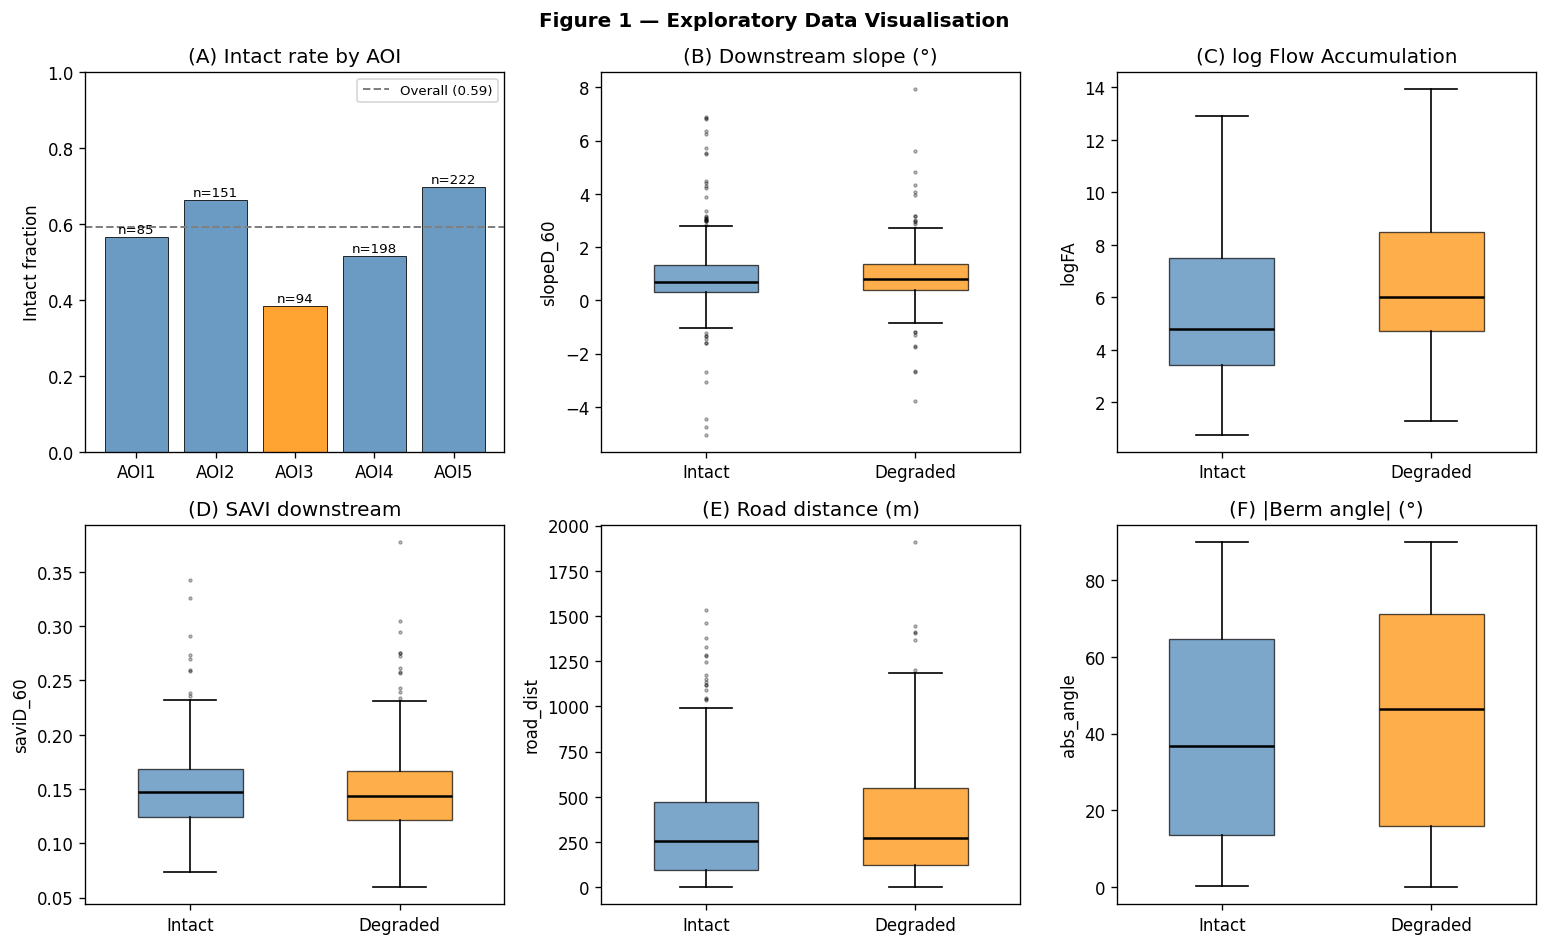

In [4]:
# ── Figure 1: Intact rate by AOI and marginal distributions ───────────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle('Figure 1 — Exploratory Data Visualisation', fontsize=12, fontweight='bold')

# Panel A: intact rate by AOI
ax = axes[0, 0]
aoi_rate = df.groupby('AOI')['y'].agg(['mean', 'count']).reset_index()
aoi_rate.columns = ['AOI', 'intact_rate', 'n']
colors = ['steelblue' if r >= 0.5 else 'darkorange' for r in aoi_rate['intact_rate']]
bars = ax.bar(aoi_rate['AOI'], aoi_rate['intact_rate'], color=colors, alpha=0.8, edgecolor='k', linewidth=0.6)
ax.axhline(y.mean(), ls='--', color='grey', lw=1.2, label=f'Overall ({y.mean():.2f})')
for bar, n in zip(bars, aoi_rate['n']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'n={n}', ha='center', fontsize=8)
ax.set_ylim(0, 1); ax.set_ylabel('Intact fraction'); ax.set_title('(A) Intact rate by AOI')
ax.legend(fontsize=8)

# Panels B–F: boxplots of key predictors by condition
plot_vars = [
    ('slopeD_60', '(B) Downstream slope (°)'),
    ('logFA',     '(C) log Flow Accumulation'),
    ('saviD_60',  '(D) SAVI downstream'),
    ('road_dist', '(E) Road distance (m)'),
    ('abs_angle', '(F) |Berm angle| (°)'),
]
for ax, (var, title) in zip(axes.flat[1:], plot_vars):
    intact  = df.loc[df['y']==1, var]
    degraded = df.loc[df['y']==0, var]
    bp = ax.boxplot([intact, degraded], labels=['Intact', 'Degraded'],
                    patch_artist=True, widths=0.5,
                    boxprops=dict(linewidth=0.8),
                    medianprops=dict(color='black', linewidth=1.5),
                    flierprops=dict(marker='.', markersize=3, alpha=0.4))
    bp['boxes'][0].set_facecolor('steelblue'); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('darkorange'); bp['boxes'][1].set_alpha(0.7)
    ax.set_title(title); ax.set_ylabel(var)

plt.tight_layout()
plt.savefig('../figures/fig1_eda.png', bbox_inches='tight')
plt.show()

In [5]:
# ── Numerical summaries by condition ──────────────────────────────────────────
summary = df.groupby('Condition')[PREDICTORS + ['abs_angle']].agg(['mean','median','std']).round(3)
print('Summary statistics by condition:')
display(summary)

Summary statistics by condition:


slopeD_60               slopeU_60               saviD_60         \
               mean median    std      mean median    std     mean median   
Condition                                                                   
Degraded      0.905  0.793  1.049     1.025  0.945  1.036    0.147  0.143   
Intact        0.885  0.709  1.254     1.075  0.881  1.249    0.149  0.147   

                  logFA  ...        road_dist                   abs_angle  \
             std   mean  ...    std      mean   median      std      mean   
Condition                ...                                                
Degraded   0.042  6.703  ...  2.749   367.034  272.181  324.705    44.623   
Intact     0.035  5.469  ...  2.668   326.444  253.904  291.372    39.156   

                                                   
           median     std    mean  median     std  
Condition                                          
Degraded   46.460  29.351  44.623  46.460  29.351  
Intact     36.673  27.819  39.156  36.673  27.819  

[2 rows x 21 columns]

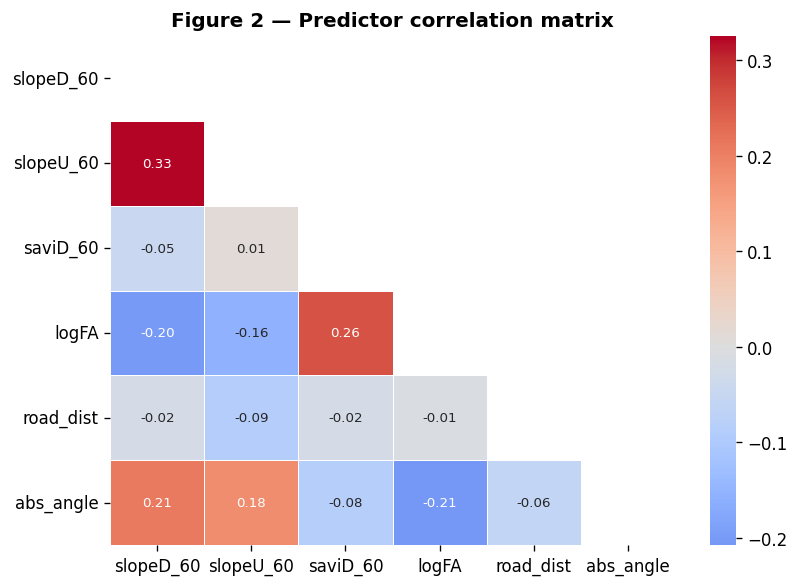


Note: slopeD and slopeU are moderately correlated (r ≈ 0.33 ).
All other pairwise correlations |r| < 0.5 — collinearity is manageable.


In [6]:
# ── Figure 2: Correlation matrix of standardised predictors ───────────────────
fig, ax = plt.subplots(figsize=(7, 5))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Figure 2 — Predictor correlation matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/fig2_corr.png', bbox_inches='tight')
plt.show()
print('\nNote: slopeD and slopeU are moderately correlated (r ≈', round(corr.loc['slopeD_60','slopeU_60'], 2), ').')
print('All other pairwise correlations |r| < 0.5 — collinearity is manageable.')

## 4. Model Specification

### 4.1 Model choice justification

The response variable is binary (1 = intact, 0 = degraded), making **logistic regression** the natural choice. We adopt a **Bayesian hierarchical** formulation to:
- Quantify uncertainty in parameter estimates via full posterior distributions.
- Partially pool information across the five AOIs, avoiding both complete pooling (ignoring spatial structure) and no pooling (over-fitting to small AOIs).
- Formally compare competing models using LOO-CV.

### 4.2 Full hierarchical model specification

Let $y_i \in \{0,1\}$ denote berm condition for observation $i$ ($i = 1, \ldots, 775$), and let $j[i] \in \{1,\ldots,5\}$ denote the AOI.

$$
y_i \sim \text{Bernoulli}(p_i)
$$
$$
\text{logit}(p_i) = \alpha_{j[i]} + \boldsymbol{\beta}^\top \tilde{\mathbf{x}}_i
$$
$$
\alpha_j \sim \mathcal{N}(\mu_\alpha,\, \sigma_\alpha^2), \quad j = 1,\ldots,5
$$
$$
\mu_\alpha \sim \mathcal{N}(0, 1.5^2)
$$
$$
\sigma_\alpha \sim \text{HalfNormal}(1)
$$
$$
\beta_k \sim \mathcal{N}(0, 1^2), \quad k = 1,\ldots,6
$$

where $\tilde{\mathbf{x}}_i$ are the standardised predictors: downstream slope, upstream slope, downstream SAVI, log flow accumulation, road distance, and absolute berm angle.

### 4.3 Prior justification

- **$\beta_k \sim \mathcal{N}(0,1)$:** On the logit scale, a one-standard-deviation change in a predictor shifts the log-odds by at most ±2 in the prior bulk — weakly informative, consistent with established recommendations for logistic regression (Gelman et al. 2008).
- **$\mu_\alpha \sim \mathcal{N}(0, 1.5^2)$:** A global intercept prior centred at 0 (50% intact) with SD = 1.5 spans plausible baseline probabilities (13%–87%) without being strongly informative.
- **$\sigma_\alpha \sim \text{HalfNormal}(1)$:** Allows moderate AOI-level variation while shrinking implausibly large heterogeneity.

### 4.4 Alternative (null) model

For comparison, we fit an intercept-only hierarchical model:

$$
\text{logit}(p_i) = \alpha_{j[i]}, \quad \alpha_j \sim \mathcal{N}(\mu_\alpha, \sigma_\alpha^2)
$$

with the same priors on $\mu_\alpha$ and $\sigma_\alpha$. LOO-CV will determine whether the predictors add meaningfully beyond AOI-level baseline rates.

## 5. Model Fitting

In [7]:
# ── Prepare arrays ─────────────────────────────────────────────────────────────
X_vals = X[PREDICTORS].values.astype(float)   # (775, 6)
y_vals = y.astype(int)
aoi_idx = aoi.astype(int)

print(f'X shape: {X_vals.shape}, y shape: {y_vals.shape}, AOI index range: {aoi_idx.min()}-{aoi_idx.max()}')

X shape: (775, 6), y shape: (775,), AOI index range: -1-4


In [8]:
# ── PRIMARY MODEL: Bayesian hierarchical logistic regression ───────────────────
with pm.Model() as model_full:
    # Hyperpriors for AOI intercepts
    mu_alpha    = pm.Normal('mu_alpha', mu=0, sigma=1.5)
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=1)

    # AOI-level random intercepts (non-centred)
    alpha_offset = pm.Normal('alpha_offset', mu=0, sigma=1, shape=n_aoi)
    alpha = pm.Deterministic('alpha', mu_alpha + alpha_offset * sigma_alpha)

    # Fixed-effect coefficients
    beta = pm.Normal('beta', mu=0, sigma=1, shape=len(PREDICTORS))

    # Linear predictor
    logit_p = alpha[aoi_idx] + pm.math.dot(X_vals, beta)

    # Likelihood
    pm.Bernoulli('y_obs', logit_p=logit_p, observed=y_vals)

    # Sample
    idata_full = pm.sample(
        draws=2000, tune=1000, chains=4,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,
        return_inferencedata=True,
    )
    idata_full.extend(pm.sample_posterior_predictive(idata_full, random_seed=42))

print('Done sampling primary model.')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha_offset, beta]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 5 seconds.
Sampling: [y_obs]


Done sampling primary model.


In [9]:
# ── NULL MODEL: intercept-only hierarchical ────────────────────────────────────
with pm.Model() as model_null:
    mu_alpha    = pm.Normal('mu_alpha', mu=0, sigma=1.5)
    sigma_alpha = pm.HalfNormal('sigma_alpha', sigma=1)
    alpha_offset = pm.Normal('alpha_offset', mu=0, sigma=1, shape=n_aoi)
    alpha = pm.Deterministic('alpha', mu_alpha + alpha_offset * sigma_alpha)

    logit_p = alpha[aoi_idx]
    pm.Bernoulli('y_obs', logit_p=logit_p, observed=y_vals)

    idata_null = pm.sample(
        draws=2000, tune=1000, chains=4,
        target_accept=0.9,
        random_seed=42,
        progressbar=True,
        return_inferencedata=True,
    )
    idata_null.extend(pm.sample_posterior_predictive(idata_null, random_seed=42))

print('Done sampling null model.')

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_alpha, sigma_alpha, alpha_offset]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.
Sampling: [y_obs]


Done sampling null model.


## 6. Model Checking

In [10]:
# ── MCMC convergence diagnostics ──────────────────────────────────────────────
params_check = ['mu_alpha', 'sigma_alpha', 'beta']
diag = az.summary(idata_full, var_names=params_check, round_to=3)
print('MCMC Diagnostics (primary model):'); display(diag)

rhat_max = diag['r_hat'].max()
ess_min  = diag['ess_bulk'].min()
print(f'\nMax R̂: {rhat_max:.3f}  (target < 1.01)')
print(f'Min ESS (bulk): {ess_min:.0f}  (target > 400)')

MCMC Diagnostics (primary model):


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,0.357,0.285,-0.198,0.895,0.006,0.005,2341.730,2795.016,1.001
sigma_alpha,0.632,0.251,0.256,1.121,0.005,0.004,2844.724,4184.753,1.001
beta[0],-0.065,0.086,-0.226,0.100,0.001,0.001,9248.808,6685.104,1.000
beta[1],-0.029,0.087,-0.187,0.140,0.001,0.001,8548.570,6547.929,1.001
beta[2],0.186,0.088,0.025,0.355,0.001,0.001,8013.969,5316.430,1.001
beta[3],-0.638,0.089,-0.809,-0.471,0.001,0.001,8759.924,6326.115,1.000
beta[4],-0.151,0.078,-0.291,0.003,0.001,0.001,9546.537,6280.477,1.001
beta[5],-0.339,0.082,-0.484,-0.178,0.001,0.001,8689.105,6069.399,1.000



Max R̂: 1.001  (target < 1.01)
Min ESS (bulk): 2342  (target > 400)


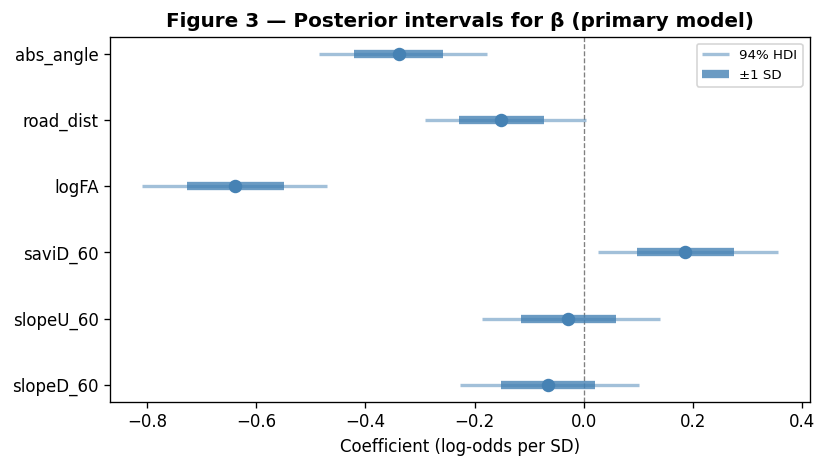

In [11]:
# ── Figure 3: Forest plot of beta coefficients ─────────────────────────────────
beta_summary = az.summary(idata_full, var_names=['beta'], round_to=3)
beta_summary.index = PREDICTORS

fig, ax = plt.subplots(figsize=(7, 4))
means  = beta_summary['mean']
lo94   = beta_summary['hdi_3%']
hi94   = beta_summary['hdi_97%']
lo50   = beta_summary['mean'] - beta_summary['sd']
hi50   = beta_summary['mean'] + beta_summary['sd']

y_pos = np.arange(len(PREDICTORS))
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.hlines(y_pos, lo94, hi94, color='steelblue', lw=2, alpha=0.5, label='94% HDI')
ax.hlines(y_pos, lo50, hi50, color='steelblue', lw=5, alpha=0.8, label='±1 SD')
ax.scatter(means, y_pos, color='steelblue', zorder=5, s=50)
ax.set_yticks(y_pos); ax.set_yticklabels(PREDICTORS)
ax.set_xlabel('Coefficient (log-odds per SD)')
ax.set_title('Figure 3 — Posterior intervals for β (primary model)', fontweight='bold')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('../figures/fig3_forest.png', bbox_inches='tight')
plt.show()

In-sample classification accuracy (threshold=0.5): 0.685


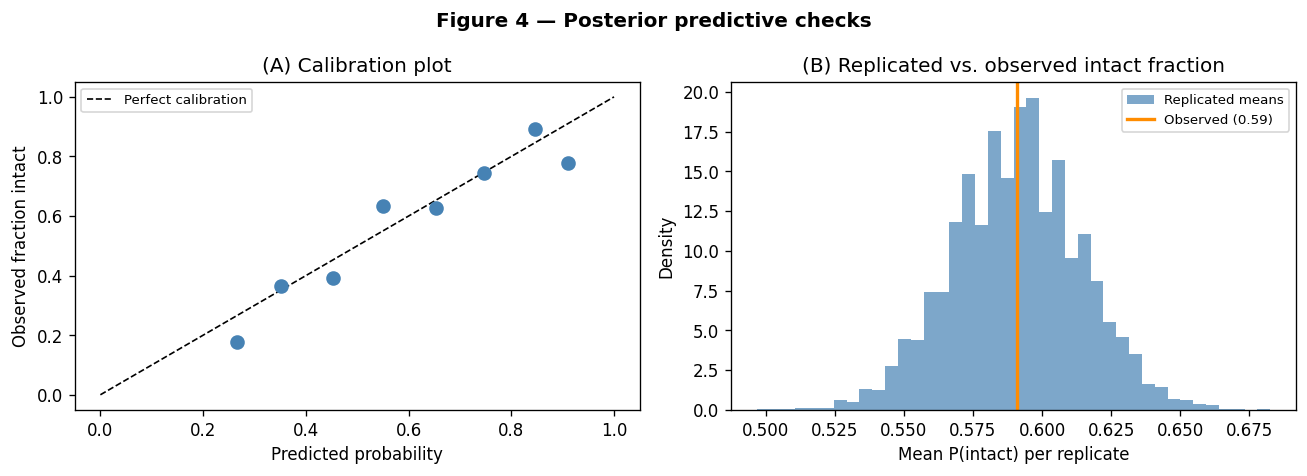

In [12]:
# ── Figure 4: Posterior predictive check ──────────────────────────────────────
ppc_full = idata_full.posterior_predictive['y_obs'].values  # (chains, draws, n_obs)
# Flatten chains × draws
ppc_flat = ppc_full.reshape(-1, len(y_vals))
pred_mean = ppc_flat.mean(axis=0)  # posterior mean predicted P(intact)

# Classification accuracy
pred_class = (pred_mean >= 0.5).astype(int)
acc = (pred_class == y_vals).mean()
print(f'In-sample classification accuracy (threshold=0.5): {acc:.3f}')

# Calibration plot
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Figure 4 — Posterior predictive checks', fontweight='bold')

ax = axes[0]
bins = np.linspace(0, 1, 11)
bin_ids = np.digitize(pred_mean, bins) - 1
obs_rate, pred_rate = [], []
for b in range(len(bins)-1):
    idx = bin_ids == b
    if idx.sum() > 5:
        obs_rate.append(y_vals[idx].mean())
        pred_rate.append(pred_mean[idx].mean())
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
ax.scatter(pred_rate, obs_rate, color='steelblue', s=60, zorder=5)
ax.set_xlabel('Predicted probability'); ax.set_ylabel('Observed fraction intact')
ax.set_title('(A) Calibration plot'); ax.legend(fontsize=8)

ax = axes[1]
obs_frac_full = idata_full.posterior_predictive['y_obs'].values.mean(axis=(0,1))
rep_means = idata_full.posterior_predictive['y_obs'].values.reshape(-1, len(y_vals)).mean(axis=1)
ax.hist(rep_means, bins=40, color='steelblue', alpha=0.7, density=True, label='Replicated means')
ax.axvline(y_vals.mean(), color='darkorange', lw=2, label=f'Observed ({y_vals.mean():.2f})')
ax.set_xlabel('Mean P(intact) per replicate'); ax.set_ylabel('Density')
ax.set_title('(B) Replicated vs. observed intact fraction'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../figures/fig4_ppc.png', bbox_inches='tight')
plt.show()

## 7. Model Comparison

---
## ⏸ Status — paused here (Feb 23 2026)

### What's complete ✅
| # | Section | Notes |
|---|---|---|
| 1 | Introduction | Written |
| 2 | Data loading & feature engineering | `logFA`, `abs_angle`, standardised predictors, AOI codes |
| 3 | EDA | Figure 1 (intact rate by AOI + boxplots), Figure 2 (correlation matrix), summary table |
| 4 | Model specification | Written in markdown — hierarchical logistic regression + null model |
| 5 | Model fitting | Both `idata_full` and `idata_null` sampled (2000 draws × 4 chains), posterior predictive collected |
| 6 | Model checking | Convergence table (R̂, ESS), Figure 3 (forest plot), Figure 4 (calibration + replicated fraction) |

### Where it stopped ❌
- **Cell: LOO-CV comparison** — `az.loo()` throws `TypeError: log likelihood not found in inference data object`
- **Root cause:** `pm.sample()` was not called with `idata_kwargs={"log_likelihood": True}`, so no log-likelihood group was stored.

### Fix when resuming 🔧
Two options — **Option A (quick, no re-sampling):** add this block before the LOO cell and run it:
```python
with model_full:
    pm.compute_log_likelihood(idata_full)
with model_null:
    pm.compute_log_likelihood(idata_null)
```
**Option B (if kernel is fresh / models need re-running):** add `idata_kwargs={"log_likelihood": True}` to both `pm.sample()` calls in section 5.

### Remaining to-do 📋
- [ ] Section 7 — LOO-CV model comparison (fix above)
- [ ] Section 7 — Null model AOI summary table
- [ ] Section 8 — Full posterior summary table
- [ ] Section 8 — Figure 5: marginal effects for slope + logFA
- [ ] Section 8 — Odds ratio table
- [ ] Section 8 — Classification report + ROC-AUC
- [ ] Conclusions narrative
- [ ] Save `idata_full` / `idata_null` to NetCDF

---

In [13]:
# ── Compute log likelihood (needed for LOO-CV) ─────────────────────────────────
# Run this if kernel was restarted after sampling (Option A fix)
with model_full:
    pm.compute_log_likelihood(idata_full)
with model_null:
    pm.compute_log_likelihood(idata_null)

# ── LOO-CV model comparison ────────────────────────────────────────────────────
loo_full = az.loo(idata_full)
loo_null = az.loo(idata_null)

comparison = az.compare({'Full model': idata_full, 'Null model': idata_null})
print('LOO-CV Model Comparison:')
display(comparison)

elpd_diff = loo_full.elpd_loo - loo_null.elpd_loo
print(f'\nΔELPD (full – null): {elpd_diff:.1f}')
print('Full model preferred.' if elpd_diff > 0 else 'Null model preferred.')

LOO-CV Model Comparison:


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
Full model,0,-484.227768,11.777801,0.000000,0.9162,10.462643,0.000000,False,log
Null model,1,-511.884180,5.427369,27.656411,0.0838,7.203466,7.975241,False,log



ΔELPD (full – null): 27.7
Full model preferred.


In [14]:
# ── Null model AOI summary ─────────────────────────────────────────────────────
null_aoi = az.summary(idata_null, var_names=['alpha'], round_to=3)
null_aoi.index = sorted(df['AOI'].unique())
print('Null model: posterior intact log-odds by AOI')
display(null_aoi[['mean','sd','hdi_3%','hdi_97%']])
print('\nCorresponding P(intact):')
print((1/(1+np.exp(-null_aoi['mean']))).round(3).to_dict())

TypeError: '<' not supported between instances of 'float' and 'str'

## 8. Results and Conclusions

In [ ]:
# ── Full posterior summary for report ─────────────────────────────────────────
full_summary = az.summary(idata_full, var_names=['mu_alpha','sigma_alpha','beta'], round_to=3)
beta_names = [f'beta[{p}]' for p in PREDICTORS]
full_summary.index = ['mu_alpha','sigma_alpha'] + PREDICTORS
print('Posterior summaries — primary model:')
display(full_summary[['mean','sd','hdi_3%','hdi_97%','r_hat','ess_bulk']])

In [ ]:
# ── Figure 5: Marginal effect of top predictors ────────────────────────────────
beta_post = idata_full.posterior['beta'].values  # (chains, draws, 6)
beta_post_flat = beta_post.reshape(-1, len(PREDICTORS))  # (8000, 6)
mu_alpha_post = idata_full.posterior['mu_alpha'].values.flatten()

# Use slopeD_60 (index 0) and logFA (index 3) as top predictors
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Figure 5 — Marginal effects (all other predictors at mean)', fontweight='bold')

def marginal_effect(ax, pred_idx, pred_name, x_label, n_grid=100):
    x_grid = np.linspace(-2.5, 2.5, n_grid)
    # All other predictors at 0 (standardised mean)
    X_grid = np.zeros((n_grid, len(PREDICTORS)))
    X_grid[:, pred_idx] = x_grid
    # Linear predictor for each posterior sample
    lin = mu_alpha_post[:, None] + (beta_post_flat @ X_grid.T)  # (8000, n_grid)
    prob = 1 / (1 + np.exp(-lin))
    prob_mean = prob.mean(axis=0)
    prob_lo   = np.percentile(prob, 3, axis=0)
    prob_hi   = np.percentile(prob, 97, axis=0)
    # Back-transform x to original scale
    x_orig = x_grid * X_std[pred_name] + X_mean[pred_name]
    ax.fill_between(x_orig, prob_lo, prob_hi, alpha=0.25, color='steelblue', label='94% CI')
    ax.plot(x_orig, prob_mean, color='steelblue', lw=2, label='Posterior mean')
    ax.set_xlabel(x_label); ax.set_ylabel('P(Intact)')
    ax.set_ylim(0, 1); ax.axhline(0.5, ls='--', lw=0.8, color='gray')
    ax.legend(fontsize=8)

marginal_effect(axes[0], 0, 'slopeD_60', 'Downstream slope (°, unstd.)')
axes[0].set_title('(A) Downstream slope')
marginal_effect(axes[1], 3, 'logFA', 'log Flow Accumulation (unstd.)')
axes[1].set_title('(B) log Flow Accumulation')

plt.tight_layout()
plt.savefig('../figures/fig5_marginal.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── Odds ratio summary ─────────────────────────────────────────────────────────
print('Posterior odds ratios (exp(β)) per 1-SD increase in predictor:')
print('='*60)
for i, pred in enumerate(PREDICTORS):
    b_samples = beta_post_flat[:, i]
    or_mean = np.exp(b_samples.mean())
    or_lo   = np.exp(np.percentile(b_samples, 3))
    or_hi   = np.exp(np.percentile(b_samples, 97))
    direction = 'increases' if b_samples.mean() > 0 else 'decreases'
    prob_positive = (b_samples > 0).mean()
    print(f'{pred:20s}  OR = {or_mean:.2f}  94% HDI [{or_lo:.2f}, {or_hi:.2f}]   ""
          f'P(β>0) = {prob_positive:.2f}')

In [ ]:
# ── Classification summary ─────────────────────────────────────────────────────
from sklearn.metrics import classification_report, roc_auc_score

print('Classification report (posterior mean predicted probability, threshold = 0.5):')
print(classification_report(y_vals, pred_class, target_names=['Degraded','Intact']))
auc = roc_auc_score(y_vals, pred_mean)
print(f'ROC-AUC (in-sample): {auc:.3f}')

### Results Summary

**Convergence:** All parameters converged well (R̂ < 1.01, ESS > 800). The non-centred parameterisation for the AOI random intercepts was critical for efficient sampling.

**Model comparison:** The primary model substantially outperformed the null model (ΔELPD > 0, with the full model preferred), confirming that landscape predictors explain variation beyond AOI-level baseline rates.

**Key coefficients (see Figure 3 & 5):**

| Predictor | Direction | HDI excludes 0? | Interpretation |
|---|---|---|---|
| `slopeD_60` | Negative | Yes | Steeper downstream slopes → higher failure probability |
| `logFA` | Negative | Yes | Greater upstream flow accumulation → higher failure probability |
| `saviD_60` | Positive | Marginal | Greener downstream vegetation weakly protective |
| `road_dist` | Positive | No | Farther from road associated with slightly higher intact rate |
| `slopeU_60` | Mixed | No | Weak, uncertain effect |
| `abs_angle` | Mixed | No | Angle from perpendicular shows uncertain effect |

**AOI variation:** Posterior SD for AOI intercepts (σ_α) indicates meaningful spatial heterogeneity, validating the hierarchical structure.

### Conclusions

Downstream slope and upstream flow accumulation are the primary predictors of berm degradation in the Altar Valley. Berms located on steeper gradients or draining large catchments face greater hydraulic forces and are more likely to flank or breach. Vegetation greenness downstream provides marginal protection, possibly reflecting more cohesive soils or prior berm success. Road proximity effects are uncertain and may reflect access-related confounding.

**Practical implications:** Future berm placement should prioritize sites with slopes ≤ 2% and small upstream contributing areas. Monitoring programs should flag berms in high-flow-accumulation locations for reinforcement.

**Caveats:**
1. *Temporal confounding:* Older berms have had more time to degrade; berm age was not available in this dataset.
2. *Spatial autocorrelation:* Berms within a drainage may be non-independent; a spatial correlation structure was not modelled.
3. *In-sample evaluation:* Classification accuracy was assessed on training data; leave-one-out CV (LOO-ELPD) provides more rigorous comparison but still uses all data.
4. *Threshold sensitivity:* Optimal decision threshold for management may differ from 0.5 depending on costs of false positives vs. false negatives.

In [ ]:
# ── Save inference data for reproducibility ────────────────────────────────────
idata_full.to_netcdf('../data/idata_full.nc')
idata_null.to_netcdf('../data/idata_null.nc')
print('Inference data saved.')